In [1]:
import numpy as np
import matplotlib.pyplot as plt
import smplotlib
import pandas as pd
from astropy import units as u, constants as const
from scipy.optimize import curve_fit

nu0 = 2295 #mega hertz

def gaussian(nus, A, nu, dnu, c):
    
    return A * np.exp(-0.5 * ((nus-nu)/dnu)**2) + c


Bad value in file '/home/a268p582/anaconda3/lib/python3.10/site-packages/smplotlib/smplot.mplstyle', line 338 ('mathtext.it:  AVHershey Complex:mediumitalic'): Key mathtext.it: 
AVHershey Complex:mediumitalic
                        ^
ParseException: Expected end of text, found 'italic'  (at char 24), (line:1, col:25)


### Part a) You measure the _round-trip_ travel time to be 1258.297 seconds. What is the current distance between Earth and Mercury?

### We'll use the fact that radio waves travel at the speed of light, d = c x t

In [2]:
t = 1258.297 * u.s

d = (const.c * t).to(u.au)/2 # Divide two since we measure the round-trip travel time!
print(d)

1.2608065501163113 AU


### Part a) Assuming we know the semi-major axes of both Earth and Mercury, what is the phase angle, $\phi$?

### Since we know all sides of a triangle connecting the Sun, Earth, and Mercury we can use the law of cosines to find the angle:

### $R_{\oplus}^2$ =  $R_{Moon}^2 + d^2 - 2dR_{Moon}\cos{\phi}$

In [3]:
a_merc = 0.38*u.au
a_earth = 1*u.au

cos_phi = -(a_earth**2-a_merc**2-d**2)/(2*d*a_merc)

phi = np.rad2deg(np.arccos(cos_phi))

print(phi)

40.00005305810524 deg


### Part c) Download the $\texttt{mercury_radar.txt}$ file from Canvas. Open it in your preferred programming language and plot the data. What do you notice about the radio signal signal you received?

Text(0.5, 0, 'Frequency - $\\nu_0$ [MHz]')

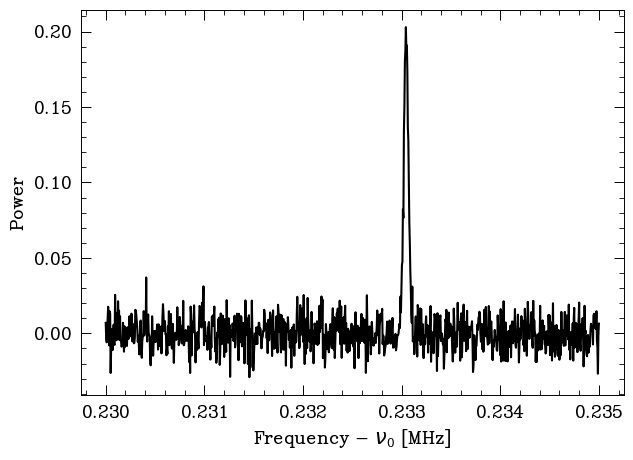

In [4]:
data = pd.read_csv("./mercury_radar.txt")

fig, ax = plt.subplots(figsize=(7,5))

ax.plot(data.frequency_mhz-nu0,data.power,c='k')

ax.set_ylabel("Power")
ax.set_xlabel(r"Frequency - $\nu_0$ [MHz]")

### We see that the radio signal we recieved is shifted by around 0.23 Mhz from the original frequency we sent to Mercury. It also seems to have acquired some width.

### Part d) Using any model fitting package/software, fit the data with a Gaussian model.


Best fit parameters:
Amplitude: 0.19
Mean frequency: 2295.233 MHz
Frequency width: 2.495e-05 MHz
Constant: -5.3e-05



Text(0.5, 0, 'Frequency - $\\nu_0$ [MHz]')

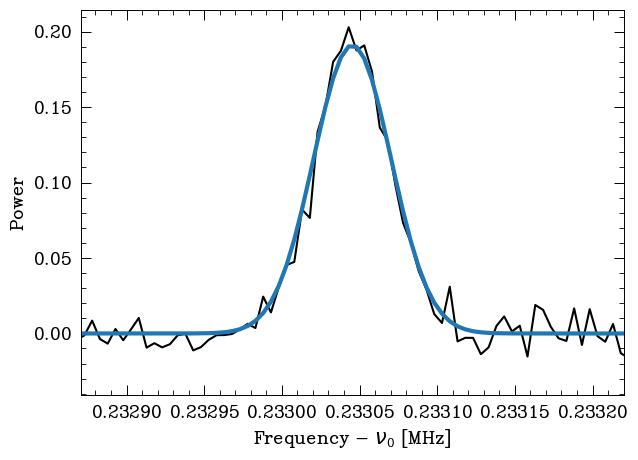

In [5]:
# Using the Gaussian function defined at the begining of the notebook:

p0 = [0.1,nu0+0.233,0.02/1e3,0] # with curve fit, we often need to help the 
                           # solver a bit by giving it rational starting values

popt, pcov = curve_fit(gaussian, data.frequency_mhz, data.power,p0)

print(rf"""Best fit parameters:
Amplitude: {popt[0]:0.2}
Mean frequency: {popt[1]:0.7} MHz
Frequency width: {popt[2]:0.4} MHz
Constant: {popt[3]:0.2}
""")



fig, ax = plt.subplots(figsize=(7,5))

ax.plot(data.frequency_mhz-nu0,data.power,c='k')

nu_plot = np.linspace(data.frequency_mhz.min(),data.frequency_mhz.max(),1000)

ax.plot(nu_plot-nu0,gaussian(nu_plot,*popt),lw=3)

ax.set_xlim((popt[1]-nu0)-7*popt[2],(popt[1]-nu0)+7*popt[2])
ax.set_ylabel("Power")
ax.set_xlabel(r"Frequency - $\nu_0$ [MHz]")

### Part e) Determine the orbital velocity of Mercury. Assume a non-relativistic Doppler shift. _Hint: Remind yourself how the Doppler effect works. Is Mercury traveling straight towards you?_

### We relate the original frequency to the observed frequency by $\nu = \nu_0 (1+\frac{v}{c})$


In [6]:
v_obs = (popt[1]/nu0-1)*const.c
v_obs = v_obs.to(u.km/u.s)
print(v_obs)

30.442371964843122 km / s


### But remember, at this phase angle Mercury is _not_ traveling directly at us. So the velocity we observed must be divided by the sine of the phase angle: $v_{orb} = \frac{v_{obs}}{\sin{\phi}}$


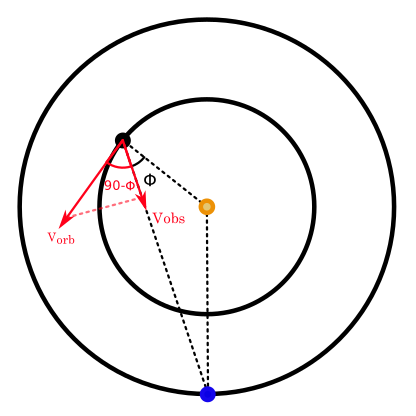

In [106]:
v_orb = v_obs / np.sin(np.radians(phi))
v_orb

<Quantity 47.35987115 km / s>

### Which is pretty much the mean orbital velocity of Mercury

### Part f) Using the principle of Doppler broadening, determine Mercury's rotational velocity and rotation period (assume that any natural broadening is negligible)

### Here we simply take the width and mean frequency of our radio signal and use $\Delta \nu = \frac{\nu v_r}{c}$

In [107]:
v_rot = (popt[2]/popt[1])*const.c
v_rot

<Quantity 3.258398 m / s>

### Which is pretty close to the mean rotational velocity of Mercury 3.026 m/s. The rotation period is just $\frac{2\pi r_{Mercury}}{v_{rot}}$

In [108]:
r_merc = 2439.4 *u.km

p_rot = (2*np.pi*r_merc.to(u.m))/v_rot
p_rot.to(u.d)

<Quantity 54.44337186 d>

### Again, pretty close to the sidereal rotation period of 58 days